# Gaussian wavepacket

The Gaussian wavepacket is given by

$$
\psi(x, 0) = A \exp (-a x^2)
$$

In [1]:
import numpy as np
from scipy.integrate import quad, quad_vec
from scipy.constants import hbar, m_e


In [2]:
A, A_vec = 1, np.asarray(1, dtype=np.complex128)
a, a_vec = 1, np.asarray(1, dtype=np.complex128)
hbar, m_e = np.asarray(hbar, dtype=np.complex128), np.asarray(m_e, dtype=np.complex128)
xmin, xmax = -10, 10
xmin_vec, xmax_vec = np.asarray(xmin, dtype=np.complex128), np.asarray(xmax, dtype=np.complex128)
kmin, kmax = -10, 10
kmin_vec, kmax_vec = np.asarray(kmin, dtype=np.complex128), np.asarray(kmax, dtype=np.complex128)

In [3]:
a_vec

array(1.+0.j)

In [4]:
a_vec.conjugate()

np.complex128(1-0j)

In [5]:
def gaussian(x):
    return A*np.exp(-1*a*x**2)

In [6]:
def gaussian_vec(x):
    x = np.asarray(x, dtype=np.complex128)
    value = A*np.exp(-1*a*x**2)
    return value.astype(np.complex128)

In [7]:
def integrand_of_norm(x):
    return gaussian(x)**2

In [8]:
def integrand_of_norm_vec(x):
    x =  np.asarray(x, dtype=np.complex128)
    value = gaussian_vec(x)*gaussian_vec(x).conjugate()
    return value.astype(np.complex128)

In [9]:
def get_norm():
    norm = quad(integrand_of_norm, -np.inf, np.inf)
    return norm[0]

In [10]:
def get_norm_vec():
    """quad_vec() takes care of vectorized integrals"""
    result = quad_vec(integrand_of_norm_vec, -np.inf, np.inf)
    return result[0]

In [11]:
# test get_norm()
norm = get_norm()

In [12]:
norm

1.2533141373155017

In [13]:
A /= np.sqrt(norm)

In [14]:
A

np.float64(0.8932438417380018)

In [15]:
# test get_norm_vec()
norm_vec = get_norm_vec()

In [16]:
norm_vec

np.complex128(0.999999999999999+0j)

The wavepacket is composed of k-waves with the coefficient $\phi(k)$

$$
\psi(x) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{+\infty} \phi(k) \exp \left[ +j k x\right]\, \mathrm{d}k
$$

where the coefficient is given by

$$
\phi(k) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{+\infty} \psi(x) \exp \left[ -j k x\right]\, \mathrm{d}x
$$

In [17]:
def integrand_of_coefficient(x, k):
    return 1/np.sqrt(2.0*np.pi)*gaussian(x)*np.exp(-1j*k*x)

In [18]:
def integrand_of_coefficient_vec(x, k):
    x =  np.asarray(x, dtype=np.complex128)
    k =  np.asarray(k, dtype=np.complex128)
    prefactor = 1/np.sqrt(2.0*np.pi)
    prefactor = np.asarray(prefactor, dtype=np.complex128)
    value = prefactor*gaussian_vec(x)*np.exp(-1j*k*x)
    return value.astype(np.complex128)

In [42]:
def get_coefficient(k):
    coefficient = quad(integrand_of_coefficient, -np.inf, np.inf, args=(k,))
    return coefficient[0]

In [43]:
def get_coefficient_vec(k):
    k =  np.asarray(k, dtype=np.complex128)
    result = quad_vec(integrand_of_coefficient_vec, -np.inf, np.inf, args=(k,))
    coefficient = result[0]
    return coefficient

In [44]:
coeff = get_coefficient(1)

In [45]:
coeff

0.4919051987112381

In [46]:
coeff_vec = get_coefficient_vec(1)

In [47]:
coeff_vec

np.complex128(0.49190519871123844-1.3877801042704258e-17j)

In [48]:
coeff_vec.real, coeff_vec.imag

(np.float64(0.49190519871123844), np.float64(-1.3877801042704258e-17))

In [49]:
ks = np.linspace(xmin, xmax)
coeffs = [get_coefficient(k) for k in ks]
coeff_vecs = [get_coefficient_vec(k) for k in ks]

Let us plot the coefficient function and check if it is also a real valued function.

In [27]:
coeff_vec_reals = [each.real for each in coeff_vecs]
coeff_vec_imags = [each.imag for each in coeff_vecs]

In [28]:
import matplotlib as mpl
import matplotlib.pyplot as plt

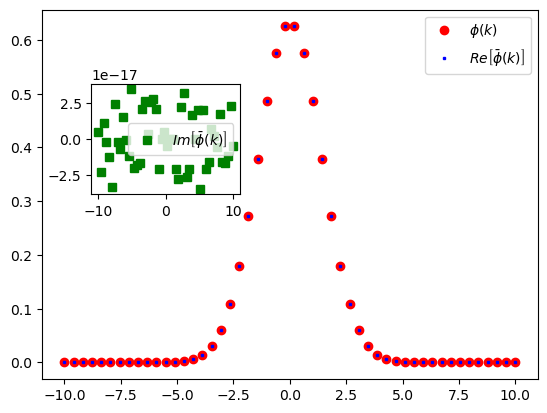

In [29]:
fig, ax = plt.subplots()
ax.plot(ks, coeffs, 'ro', lw=3, label=r'$\phi(k)$')
ax.plot(ks, coeff_vec_reals, 'bs', lw=3, ms =2, label=r'$Re\left[\bar{\phi}(k)\right]$')
ax1 = ax.inset_axes([0.1,0.5, 0.3, 0.3])
ax1.plot(ks, coeff_vec_imags, 'gs', label=r'$Im\left[\bar{\phi}(k)\right]$')
ax.legend()
ax1.legend()

## Time evolution of wave packet
The wavepacket evolves in time. Each k-wave picks up a phase over time with the phase factor given by

$$
\exp \left[ - j \frac{E(k)t}{2m} \right],
$$

where $E(k)$ is given by

$$
E(k) = \frac{\hbar^2 k^2}{2m}
$$

So the contribution to the wavepacket from k-wave changes from

$$
\phi (k) \exp \left[ +j k x\right]
$$

to

$$
\phi (k) \exp \left[ - j \frac{E(k)t}{\hbar} \right] \exp  \left[ +j k x\right]
$$

In [30]:
def energy(k):
    return hbar**2*k**2/(2*m_e)

In [31]:
def energy_vec(k):
    k =  np.asarray(k, dtype=np.complex128)
    value = np.pow(hbar, 2+0j)*np.pow(k, 2+0j)/((2+0j)*m_e)
    return value.astype(np.complex128)

In [32]:
def integrand_of_wave(k, x, t):
    coefficient = get_coefficient(k)
    temporal_phase = np.exp(-1j*energy(k)*t/hbar)
    spatial_phase = np.exp(1j*k*x)
    return 1/np.sqrt(2.0*np.pi)*coefficient*temporal_phase*spatial_phase

In [50]:
def integrand_of_wave_vec(k, x, t):
    x =  np.asarray(x, dtype=np.complex128)
    #k =  np.asarray(k, dtype=np.complex128)
    t =  np.asarray(t, dtype=np.complex128)
    prefactor = 1/np.sqrt(2.0*np.pi)
    prefactor =  np.asarray(prefactor, dtype=np.complex128)
    coefficient_vec = get_coefficient_vec(k)
    temporal_phase_vec = np.exp(-1j*energy_vec(k)*t/hbar)
    spatial_phase_vec = np.exp(1j*k*x)
    value = prefactor*coefficient_vec*temporal_phase_vec*spatial_phase_vec
    return value.astype(np.complex128)

In [34]:
def wave(x, t):
    psi = quad(integrand_of_wave, kmin, kmax, args=(x, t))
    return psi[0]

In [35]:
def wave_vec(x, t):
    x =  np.asarray(x, dtype=np.complex128)
    t =  np.asarray(t, dtype=np.complex128)
    result = quad_vec(integrand_of_wave_vec, kmin, kmax, args=(x, t))
    value = result[0]
    return value.astype(np.complex128)

In [36]:
# test wave()
w, werror = quad(integrand_of_wave, kmin, kmax, args=(-2, 10))

/home/fubar/miniconda3/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:609: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagie(func, bound, infbounds, args, full_output,
/home/fubar/miniconda3/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:607: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)


In [37]:
w

0.016360123344360353

In [51]:
# test wave_vec
w_vec, werror_vec = quad_vec(integrand_of_wave_vec, kmin, kmax, args=(-2, 10))

In [52]:
w_vec

np.complex128(0.016360123344357685+0.0001325802200246036j)

## Spread of the wavepacket

Let us define the timescale of the problem

$$
t_0 = \frac{m_e}{2\hbar a}
$$

For $t \gg t_0$, the Full Width at Half Maximum (FWHM) of the wavepacket is given by

$$
\text{FWHM}_{x(t)} \simeq  2\sqrt{\frac{\ln 2}{a}} \frac{t}{t_0}
$$

In [53]:
t0 = m_e/(2.0*hbar*a)

In [54]:
t0

np.complex128(4318.996374392254+0j)

In [55]:
ts = np.linspace(0, 10*t0, 10)
xs = np.linspace(xmin, xmax, 50)
waves = np.zeros((len(ts), len(xs)))
wave_vecs = np.zeros((len(ts), len(xs)))

In [56]:
for i, t in enumerate(ts):
    for j, x in enumerate(xs):
        waves[i][j] = wave(x, t)

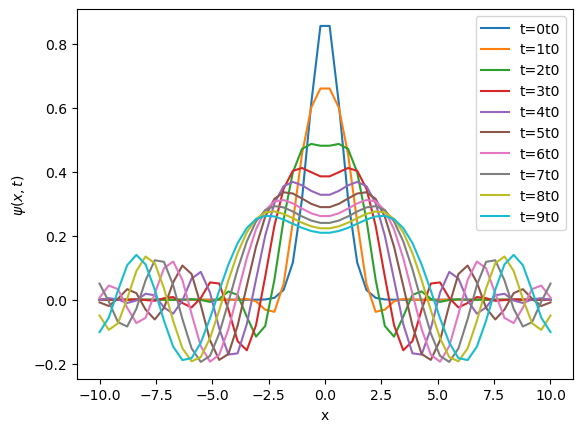

In [57]:
fig, ax = plt.subplots()
for i in range(len(waves)):
    ax.plot(xs, waves[i], label=f't={i}t0')
ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x,t)$')
ax.legend()

In [58]:
for i, t in enumerate(ts):
    for j, x in enumerate(xs):
        wave_vecs[i][j] = wave_vec(x, t)

/tmp/ipykernel_410879/71966703.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  wave_vecs[i][j] = wave_vec(x, t)


In [60]:
wave_vecs[0][0]

np.float64(-5.273322985997755e-13)

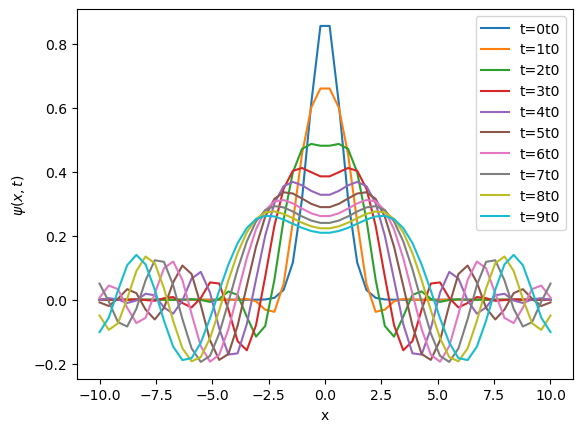

In [59]:
fig, ax = plt.subplots()
for i in range(len(wave_vecs)):
    ax.plot(xs, wave_vecs[i], label=f't={i}t0')
ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x,t)$')
ax.legend()

In [ ]:
wave_vecs[0]

In [ ]:
ts

In [ ]:
xs

In [ ]:
ks= np.linspace(-10, 10, 100)
w0s = [integrand_of_wave(k, -2, 0) for k in ks]
w, werror = quad(integrand_of_wave, -10, 10, args=(-2, 0))

In [ ]:
fig, ax = plt.subplots()
ax.plot(ks, w0s, 'ro-', lw=3, label=r'$\phi (k) \exp \left[ - j \frac{E(k)t}{\hbar} \right] \exp  \left[ +j k x\right]$')
ax.set_xlabel('k')
ax.legend()

In [ ]:
w

In [ ]:
import this